# Insights & Evaluation
This notebook contains the scripts for generating insights and evaluation for the generalisation tests

## TODO:
1. Overall insights based upon the model
2. Overall insights based upon the dimension
3. Insights per environment
4. Insights per activity
5. Insights per distance
6. Insights per user


In [44]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import json
from sklearn.model_selection import KFold, train_test_split
from keras.optimizers import Adam
from keras.models import Model, load_model
from keras.layers import Dense, Input, Flatten, Conv3D, BatchNormalization, Dropout, Conv2D
from keras.callbacks import EarlyStopping
from datetime import datetime

DATASET = "dataset_main"
MODEL_TEMPORAL = 'temporal'
MODEL_BASE = 'base'
EXP_FORMATTED_PATH = os.path.join("..", DATASET, "expformatted")
KINECT_PATH = os.path.join(EXP_FORMATTED_PATH, "kinect")
MMWAVE_PATH = os.path.join(EXP_FORMATTED_PATH, "mmWave")
MARS_PATH = os.path.join(EXP_FORMATTED_PATH, "mars")
RESULT_PATH = os.path.join("..", "main_results")
NUM_KEYPOINTS = 57
BATCH_SIZE = 128
EPOCHS = 150
MODEL_PATH = os.path.join("..", "model", "main_tests")

LOG_PATH = os.path.join("..", DATASET, "log")
LOG_MMWAVE_PATH = os.path.join(LOG_PATH, "mmWave")
LOG_KINECT_PATH = os.path.join(LOG_PATH, "kinect")

EXPERIMENT_LIST = ["E1", "E2", "E3", "A1", "A2", "A3", "D1", "U1", "U2"]

In [42]:
def read_json(filename):
    data = None
    with open(filename, "r") as f:
        data = json.loads(f.read())
    return data

def load_json(filename):
    data = None
    with open(filename, "r") as f:
        data = json.loads(f.read())
    return data


def load_dataset(dataset):
    mmwave_data = []
    kinect_data = []
    mars_data = []
    
    # TODO: Check for G1
    if 'CBCA' in dataset:
        dataset.append('G1')

    for experiment in dataset:
        mmw = np.load(os.path.join(MMWAVE_PATH, f"{experiment}.npy"))
        mmwave_data.append(mmw)
        kin = np.load(os.path.join(KINECT_PATH, f"{experiment}.npy"))
        kinect_data.append(kin)
        mars = np.load(os.path.join(MARS_PATH, f"{experiment}.npy"))
        mars_data.append(mars)
    return np.concatenate(mmwave_data, axis=0), \
        np.concatenate(kinect_data, axis=0), \
        np.concatenate(mars_data, axis=0)

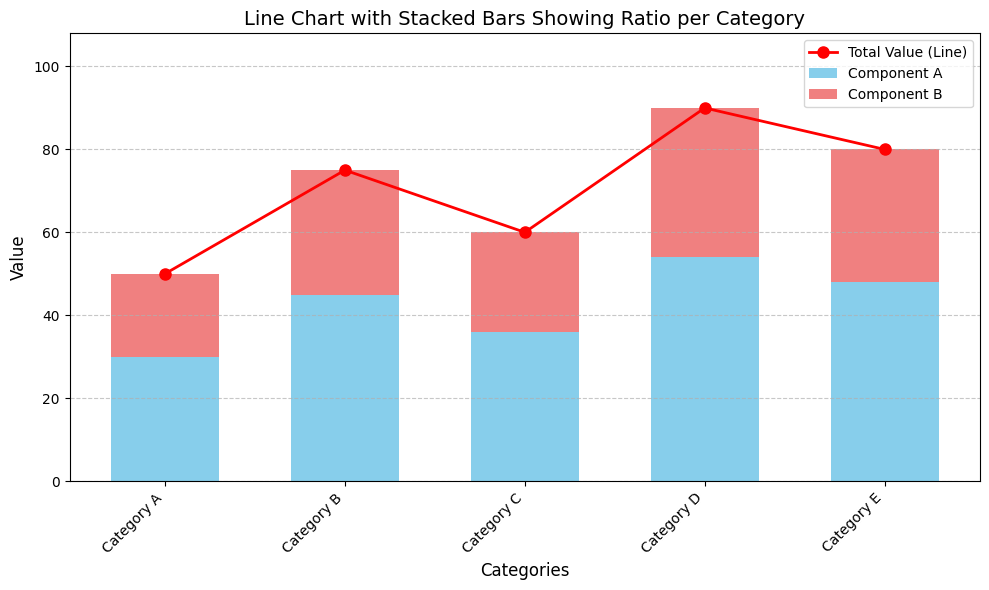

In [269]:
import matplotlib.pyplot as plt
import numpy as np

def create_line_bar_ratio_chart():
    """
    Generates a Matplotlib figure with a line chart and stacked bar charts
    showing a ratio for each category.
    """

    # 1. Define categories for the x-axis
    categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
    x_positions = np.arange(len(categories)) # Numerical positions for plotting

    # 2. Generate data for the line chart (total values)
    # These values will also be the total height of each stacked bar
    line_values = np.array([50, 75, 60, 90, 80])

    # 3. Generate data for the ratio within each bar
    # We'll divide each line_value into two components (e.g., 60% and 40%)
    # Ensure component_a_values + component_b_values = line_values
    component_a_ratio = 0.6 # Example: Component A takes 60% of the total
    component_b_ratio = 1 - component_a_ratio # Component B takes the remaining 40%

    component_a_values = line_values * component_a_ratio
    component_b_values = line_values * component_b_ratio

    # 4. Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6)) # Set figure size for better readability

    # 5. Plot the line chart
    # Use 'o-' for circles at points and a line connecting them
    ax.plot(x_positions, line_values, color='red', marker='o', linestyle='-',
            linewidth=2, markersize=8, label='Total Value (Line)')

    # 6. Plot the stacked bar chart
    # Plot component A first
    bar_width = 0.6 # Adjust bar width as needed
    ax.bar(x_positions, component_a_values, bar_width, color='skyblue', label='Component A')
    # Plot component B on top of component A
    ax.bar(x_positions, component_b_values, bar_width, bottom=component_a_values,
            color='lightcoral', label='Component B')

    # 7. Customize the plot
    # Set x-axis ticks to categories
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=45, ha='right') # Rotate labels for better fit

    # Add labels for x and y axes
    ax.set_xlabel('Categories', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)

    # Add a title
    ax.set_title('Line Chart with Stacked Bars Showing Ratio per Category', fontsize=14)

    # Add a legend
    ax.legend()

    # Add a grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust y-axis limits to ensure bars and line are fully visible
    ax.set_ylim(0, max(line_values) * 1.2) # Give a little extra space at the top

    # Ensure tight layout to prevent labels from being cut off
    plt.tight_layout()

    # Display the plot
    plt.show()

# Call the function to create and display the chart
# if __name__ == '__main__':
create_line_bar_ratio_chart()


-2.5684688859525486e-05
{'E1': {'tmars': -2.5684688859525486e-05, 'bmars': -0.003794401622305892}, 'E2': {'tmars': 0.001763754123721206, 'bmars': -0.0016910222548480452}, 'E3': {'tmars': 0.008350510885779188, 'bmars': 0.027201994371906523}, 'A1': {'tmars': 0.002464614066390055, 'bmars': 0.01507715480725157}, 'A2': {'tmars': 0.02137784893721666, 'bmars': 0.023710071597313743}, 'A3': {'tmars': 0.005104104015957303, 'bmars': 0.0010270854679638795}, 'D1': {'tmars': 0.015137245595476748, 'bmars': 0.003297081181581275}, 'U1': {'tmars': 0.06993372225321552, 'bmars': 0.07645031011637594}, 'U2': {'tmars': 0.018343457623676365, 'bmars': 0.025251214744723745}}


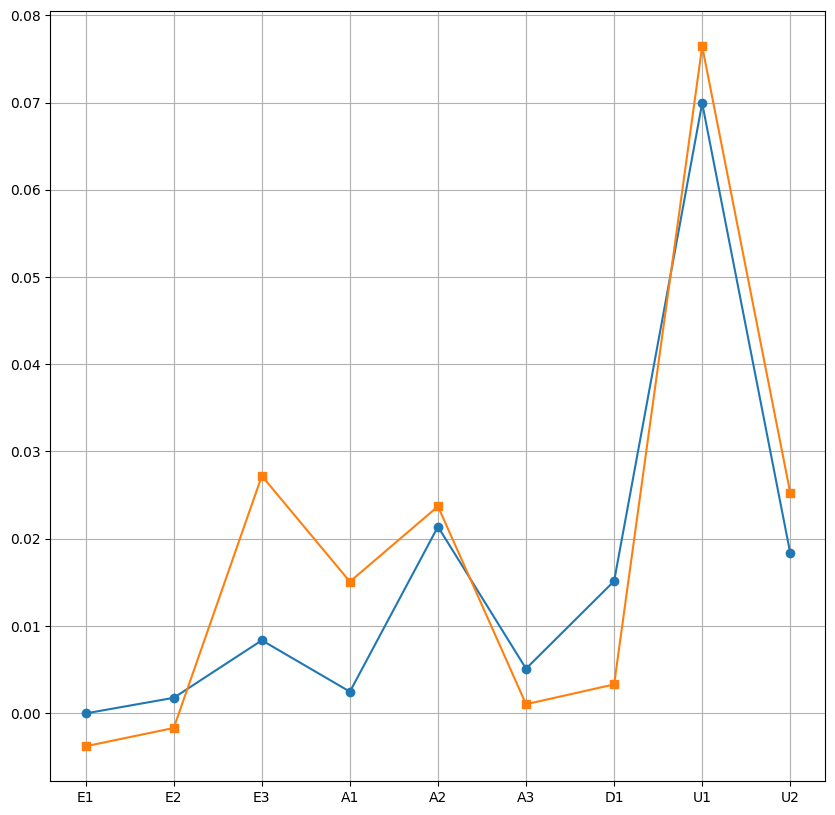

In [270]:
# Crazy result
exp_results = {}

for exp in EXPERIMENT_LIST:
    result = read_json(os.path.join(RESULT_PATH, f"{exp}_test_result.json"))
    exp_results[exp] = result

new_metric = {}
# ratio = {}
for exp in exp_results:
    new_metric[exp] = {}
    data = exp_results[exp]['tmars']
    new_metric[exp]['tmars'] = data['g']*data['test']['mae']
    data = exp_results[exp]['bmars']
    new_metric[exp]['bmars'] = data['g']*data['test']['mae']


import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
x_values = new_metric.keys()
print(new_metric['E1']['tmars'])
y_values = [new_metric[exp]['tmars'] for exp in x_values]
y2_values = [new_metric[exp]['bmars'] for exp in x_values]
plt.plot(x_values, y_values, marker="o")
plt.plot(x_values, y2_values, marker = "s")
plt.grid(True)
print(new_metric)

In [271]:
# Get difference between models
tmars_g = []
tmars_mae = []
bmars_g = []
bmars_mae = []

for exp in EXPERIMENT_LIST:
    data = exp_results[exp]
    tmars_g.append(data['tmars']['g'])
    tmars_mae.append(data['tmars']['test_mae'])
    bmars_g.append(data['bmars']['g'])
    bmars_mae.append(data['bmars']['test_mae'])

g_diff = np.array(bmars_g) - np.array(tmars_g)
mae_diff = np.array(bmars_mae) - np.array(tmars_mae)

avg_g = np.mean(g_diff)
avg_mae = np.mean(mae_diff)

In [272]:
# G, MAE diff between dimensions

dim_results = {}
models = ['tmars', 'bmars']
for exp in EXPERIMENT_LIST:
    data = exp_results[exp]
    if exp[0] not in dim_results:
        dim_results[exp[0]] = {"tmars":{"g":[], "mae": []}, "bmars": {"g": [], "mae": []}}
    for model in models:
        dim_results[exp[0]][model]['g'].append(data[model]['g'])
        dim_results[exp[0]][model]['mae'].append(data[model]['test_mae'])

for dim in dim_results:
    for model in models:
        dim_results[dim][model]['g'] = np.mean(dim_results[dim][model]['g'])
        dim_results[dim][model]['mae'] = np.mean(dim_results[dim][model]['mae']) 

In [273]:
exp_diff = {}
for experiment in EXPERIMENT_LIST:
    data = exp_results[experiment]
    exp_diff[experiment] = {'g':data['tmars']['g'] - data['bmars']['g'], 'mae': data['tmars']['test_mae'] - data['bmars']['test_mae']}

exp_diff

{'E1': {'g': 0.06595578346096925, 'mae': -0.015362929436333314},
 'E2': {'g': 0.0665273087724837, 'mae': -0.013733677927091709},
 'E3': {'g': -0.3036422737594462, 'mae': -0.003404377696848246},
 'A1': {'g': -0.1832281428345506, 'mae': -0.018422567533796244},
 'A2': {'g': 0.06906068122184483, 'mae': -0.026807856364067184},
 'A3': {'g': 0.08818601404235472, 'mae': -0.011882466088174476},
 'D1': {'g': 0.2441008084697168, 'mae': -0.012534695183417197},
 'U1': {'g': 0.09665836014921148, 'mae': -0.02331063198346145},
 'U2': {'g': -0.019365433586154612, 'mae': -0.032070750155384256}}

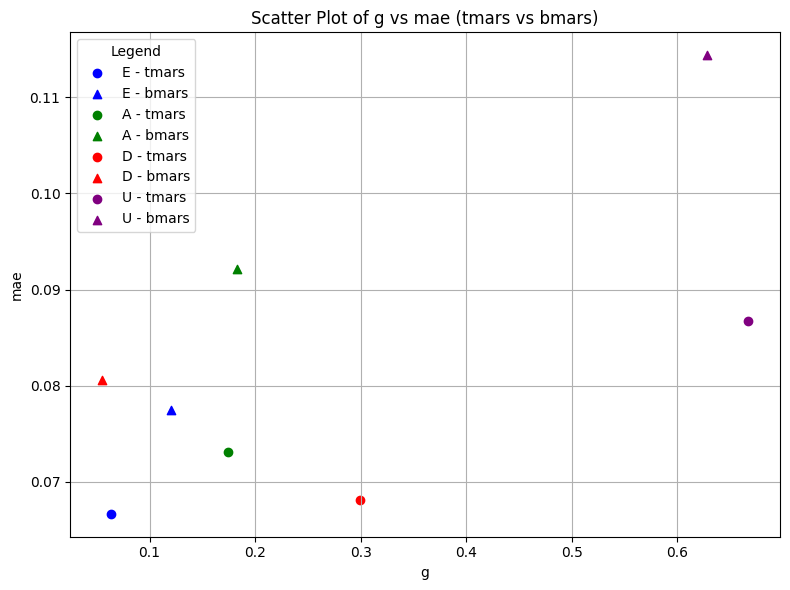

In [274]:
import matplotlib.pyplot as plt

# Input data
data = dim_results

# Define marker shapes and colors
markers = {'tmars': 'o', 'bmars': '^'}
colors = {'E': 'blue', 'A': 'green', 'D': 'red', 'U': 'purple'}

# Create the scatter plot
plt.figure(figsize=(8, 6))

for label, models in data.items():
    for model, values in models.items():
        plt.scatter(
            values['g'], values['mae'],
            color=colors[label],
            marker=markers[model],
            label=f"{label} - {model}"
        )

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys(), title="Legend")

# Labeling
plt.xlabel('g')
plt.ylabel('mae')
plt.title('Scatter Plot of g vs mae (tmars vs bmars)')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [275]:
# Find the percentage of errors per experiment
# Why? I want to see whether the high error rate for let's say user is because of environment, specific action, or distance. Similary for all experiments I want to see this. 
# What will this show? Whether the error is because of 




57


# Comparing Temporal and Baseline MARS models G and Test MAE values

In [45]:
# For each experiment, run the model on test set and continuously calculate all the average together
from sklearn.model_selection import train_test_split
import os
import json
import numpy as np


temporal_train, temporal_mae, temporal_g = [], [], []
baseline_train, baseline_mae, baseline_g = [], [], []
ARM_JOINTS = [4,5,6, 8, 9, 10]

model_list = os.listdir(MODEL_PATH)
experiment_splits = load_json("generalisation_test_splits.json")

def perform_split(train_features, train_labels):
    _, train_val, _, label_val = train_test_split(
        train_features, train_labels, test_size=0.25, random_state=888, shuffle = True
    )
    return train_val, label_val

def extract_mae(result):
    return np.mean(np.array(result['joint_mae'])[ARM_JOINTS])

def calculate_mae(predicted, groundtruth):
    print(f"shape: {predicted.shape} {groundtruth.shape}")
    # Reshape to (n, 19, 3)
    pred_reshaped = predicted.reshape(-1, 19, 3)
    gt_reshaped = groundtruth.reshape(-1, 19, 3)
    
    abs_error = np.abs(pred_reshaped - gt_reshaped)
    overall_mae = np.mean(abs_error)
    
    # # Average over samples and coordinates per joint
    jointwise_mae = np.mean(abs_error, axis=(2))  # shape: (19,)
    arm_mae_jointwise = jointwise_mae[:, ARM_JOINTS]  # Shape: (48049, 6)

# Compute average MAE across the selected joints per sample
    arm_mae = np.mean(arm_mae_jointwise, axis=1) 
    return arm_mae


for exp in EXPERIMENT_LIST:
    print(f"Running {exp}")
    mmwave_test, kinect_test, mars_test = load_dataset(experiment_splits[exp]['test'])
    mmwave_train, kinect_train, mars_train = load_dataset(experiment_splits[exp]['train'])
    
    tmars_model = load_model(os.path.join(MODEL_PATH, f"tmars_{exp}.h5"))
    bmars_model = load_model(os.path.join(MODEL_PATH, f"bmars_{exp}.h5"))

    mmwave_val, kinect_mmwave_val = perform_split(mmwave_train, kinect_train)
    mars_val, kinect_mars_val = perform_split(mars_train, kinect_train)

    predicted_temporal_test = tmars_model.predict(mmwave_test)
    test_arm_mae = calculate_mae(predicted_temporal_test, kinect_test)
    temporal_mae.extend(test_arm_mae)

    predicted_temporal_train = tmars_model.predict(mmwave_val)
    train_arm_mae = calculate_mae(predicted_temporal_train, kinect_mmwave_val)
    temporal_train.append(train_arm_mae)
    arm_g = (np.mean(test_arm_mae) - np.mean(train_arm_mae)) / np.mean(train_arm_mae)
    temporal_g.append(arm_g)


    predicted_base_test = bmars_model.predict(mars_test)
    test_arm_mae = calculate_mae(predicted_base_test, kinect_test)
    baseline_mae.extend(test_arm_mae)

    predicted_base_train = bmars_model.predict(mars_val)
    train_arm_mae = calculate_mae(predicted_base_train, kinect_mars_val)
    baseline_train.extend(train_arm_mae)
    arm_g = (np.mean(test_arm_mae) - np.mean(train_arm_mae)) / np.mean(train_arm_mae)
    baseline_g.append(arm_g)
    # run


Running E1
1502/1502 [==============================] - 11s 7ms/step
shape: (48049, 57) (48049, 57)
1114/1114 [==============================] - 8s 7ms/step
shape: (35640, 57) (35640, 57)
1502/1502 [==============================] - 3s 2ms/step
shape: (48049, 57) (48049, 57)
1114/1114 [==============================] - 2s 2ms/step
shape: (35640, 57) (35640, 57)
Running E2
2356/2356 [==============================] - 17s 7ms/step
shape: (75379, 57) (75379, 57)
901/901 [==============================] - 6s 7ms/step
shape: (28807, 57) (28807, 57)
2356/2356 [==============================] - 5s 2ms/step
shape: (75379, 57) (75379, 57)
901/901 [==============================] - 2s 2ms/step
shape: (28807, 57) (28807, 57)
Running E3
2100/2100 [==============================] - 14s 7ms/step
shape: (67178, 57) (67178, 57)
965/965 [==============================] - 6s 7ms/step
shape: (30857, 57) (30857, 57)
2100/2100 [==============================] - 5s 2ms/step
shape: (67178, 57) (67178, 57)
96

In [ ]:
print()

597988

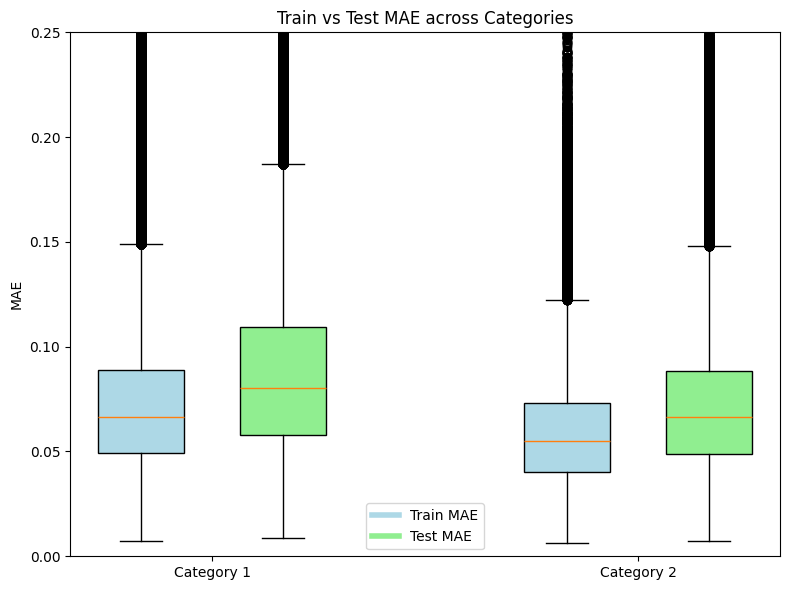

In [54]:
import matplotlib.pyplot as plt
import numpy as np

tt = []
for t in temporal_train:
    tt.extend(t)

# Example data (replace with your MAE values)
train_cat1 = baseline_train  # Train MAE for Category 1
test_cat1  = baseline_mae  # Test MAE for Category 1
train_cat2 = tt  # Train MAE for Category 2
test_cat2  = temporal_mae  # Test MAE for Category 2

data = [train_cat1, test_cat1, train_cat2, test_cat2]

# Positions for grouped boxplots
positions = [1, 2, 4, 5]  # gap between categories

fig, ax = plt.subplots(figsize=(8, 6))

# Create boxplots
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True)

# Colors for Train vs Test
colors = ['lightblue', 'lightgreen', 'lightblue', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# X-ticks: set category names in the middle of each group
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(['Category 1', 'Category 2'])

# Labels
ax.set_ylabel("MAE")
ax.set_title("Train vs Test MAE across Categories")

# Add legend
train_patch = plt.Line2D([0], [0], color='lightblue', lw=4, label='Train MAE')
test_patch = plt.Line2D([0], [0], color='lightgreen', lw=4, label='Test MAE')
ax.legend(handles=[train_patch, test_patch])
ax.set_ylim((0., 0.25))
plt.tight_layout()
plt.show()


In [ ]:
np.mean(temporal_g), np.mean(baseline_g)

(0.2605603556896996, 0.2467544550300947)

0.0739862100590762 0.07239555918301382


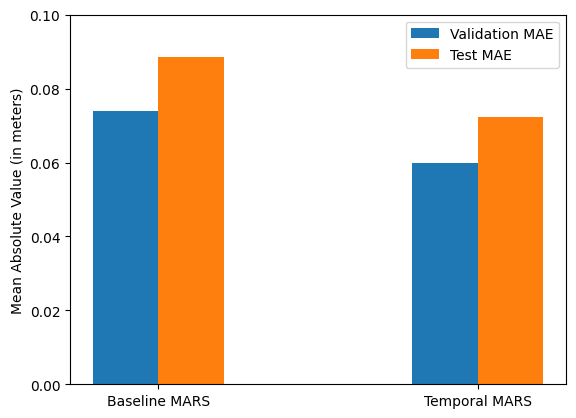

In [62]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os

# Data
labels = ['Baseline MARS', 'Temporal MARS']

tt = []
for t in temporal_train:
    tt.extend(t)

category1 = [np.mean(baseline_train), np.mean(tt)]
category2 = [np.mean(baseline_mae), np.mean(temporal_mae)]
x = np.arange(len(labels))  # the label locations
width = 0.205 # the width of the bars
print(np.mean(baseline_train), np.mean(temporal_mae))
# Plotting
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, category1, width, label='Validation MAE')
bars2 = ax.bar(x + width/2, category2, width, label='Test MAE')

# Labels and title
ax.set_ylabel('Mean Absolute Value (in meters)')
# ax.set_title('Baseline vs Temporal MARS Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim((0., 0.1))
ax.legend()

plt.show()

-1.44140625
-3.650390625
-1.1328125


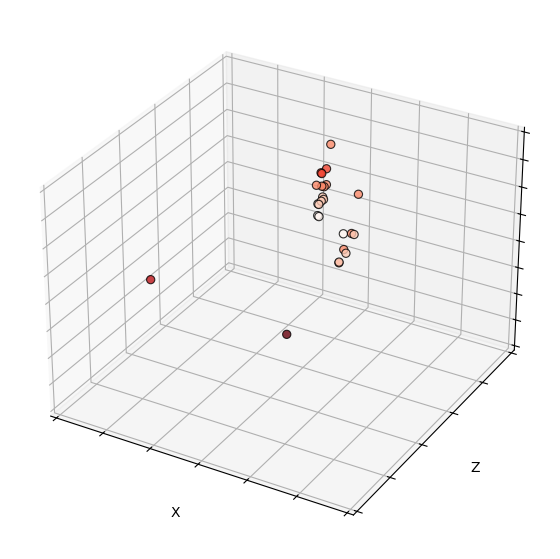

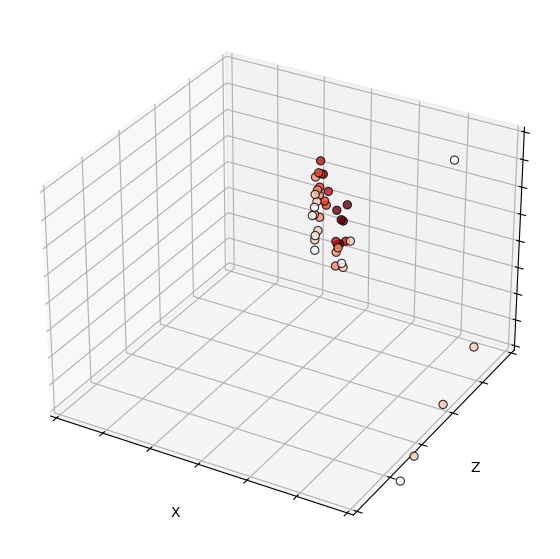

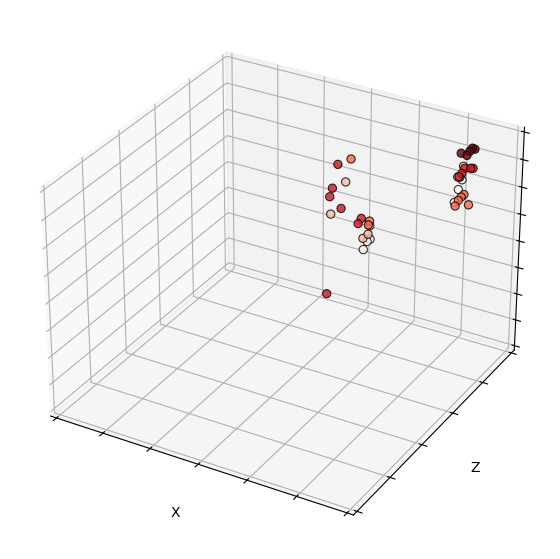

In [74]:
# Environment noise difference

import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const

EXP_FORMATTED_PATH = os.path.join('..', 'dataset_main', 'expformatted', 'mars')

EXP_A = 'BAAA'
EXP_B = 'BBAA'
EXP_C = 'BCAA'
chosen_index = [27, 10, 63]

def plot_boundingbox(ax):
    bb_height = 1.8
        


def setup_3D_subplot(subplot):
    axis_dim = const.V_3D_AXIS
    subplot.set_xlim(-3, 3)
    subplot.set_ylim(0, 2.5)
    subplot.set_zlim(0, 2)
    subplot.set_xlabel("X")
    subplot.set_ylabel("Z")
    subplot.set_zlabel("Y")
    # subplot.invert_yaxis()
    subplot.invert_xaxis()
    return subplot.scatter([], [], [])

idx=0
# Create the three figures for each
for exp in [EXP_A, EXP_B, EXP_C]:
    data = np.load(os.path.join(EXP_FORMATTED_PATH, f"{exp}.npy"))
    # print(chosen_index[idx])
    data = data[chosen_index[idx]][0]
    x_values = data[:,:,0]
    y_values = data[:,:,1]
    z_values = data[:,:,2]

    non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

    # Apply the mask to all data arrays
    x_filtered = x_values[non_zero_mask]
    y_filtered = y_values[non_zero_mask]
    z_filtered = z_values[non_zero_mask]

    print(min(x_filtered.tolist()))
    intensity = data[:,:,3][non_zero_mask]

    idx+=1
    # plt.clear()
    fig = plt.figure(figsize=(10, 7)) # Set the figure size for better visualization
    ax = fig.add_subplot(111, projection='3d')
    setup_3D_subplot(ax)
    scatter = ax.scatter(x_filtered, y_filtered, z_filtered, c=intensity, cmap='Reds', s=35, alpha=0.8,
                          edgecolors='black',
        linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    # cbar = plt.colorbar(scatter)
    # cbar.set_label("Received Signal Intensity")




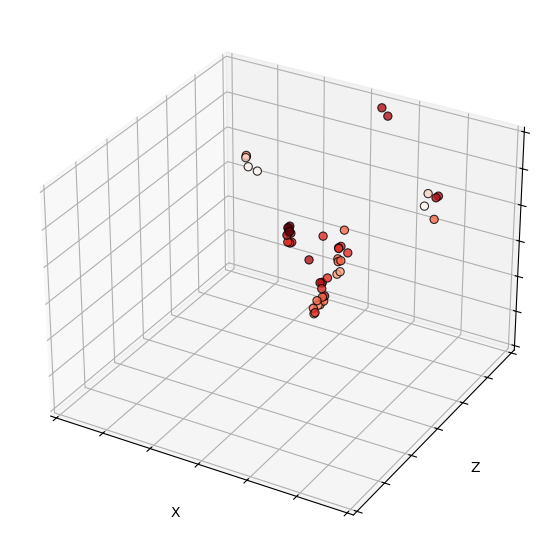

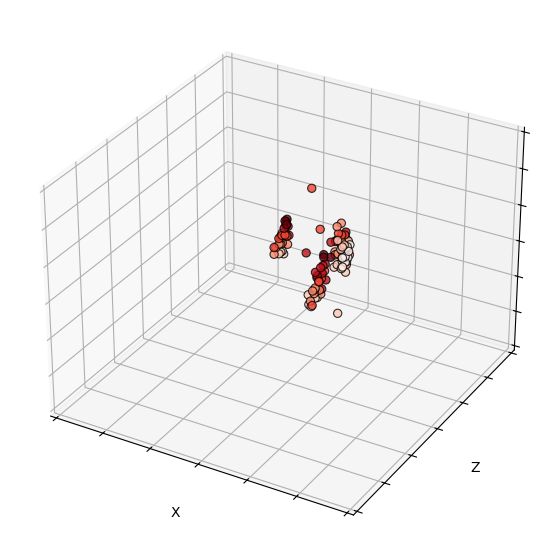

In [80]:
# Noise difference between baseline and temporal mars
# Environment noise difference

import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const

BMARS_PATH = os.path.join('..', 'dataset_main', 'expformatted', 'mars')
TMARS_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")
models = ['bmars', 'tmars']
EXPERIMENT = "ACCA"
chosen_index = [19, 19]

def setup_3D_subplot(subplot):
    axis_dim = const.V_3D_AXIS
    subplot.set_xlim(-3, 3)
    subplot.set_ylim(0, 3)
    subplot.set_zlim(0, 3)
    subplot.set_xlabel("X")
    subplot.set_ylabel("Z")
    subplot.set_zlabel("Y")
    subplot.set_xticklabels([])
    subplot.set_yticklabels([])
    subplot.set_zticklabels([])
    # subplot.invert_yaxis()
    subplot.invert_xaxis()
    return subplot.scatter([], [], [])

idx=0
for exp in models:
    if exp == 'bmars':
        data = np.load(os.path.join(BMARS_PATH, f"{EXPERIMENT}.npy"))
        # print(chosen_index[idx])
        data = data[chosen_index[idx]][0]        
        x_values = data[:,:,0]
        y_values = data[:,:,1]
        z_values = data[:,:,2]
        intensity = data[:,:,3]


    else:
        data = np.load(os.path.join(TMARS_PATH, f"{EXPERIMENT}.npy"))
        data = data[chosen_index[idx]]      
        x_values = data[:,:,:, 0]
        y_values = data[:,:,: ,1]
        z_values = data[:,:,:, 2]
        intensity = data[:,:, : ,3]


    
    non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

    # Apply the mask to all data arrays
    x_filtered = x_values[non_zero_mask]
    y_filtered = y_values[non_zero_mask]
    z_filtered = z_values[non_zero_mask]

    if exp == 'tmars':
        y_filtered += 2.

    intensity = intensity[non_zero_mask]
    # print(min(x_filtered.tolist()))

    idx+=1
    # plt.clear()
    fig = plt.figure(figsize=(10, 7)) # Set the figure size for better visualization
    ax = fig.add_subplot(111, projection='3d')
    setup_3D_subplot(ax)
    scatter = ax.scatter(x_filtered, y_filtered, z_filtered, c=intensity, cmap='Reds', s=35, alpha=0.8,
                          edgecolors='black',
        linewidth=0.8)

    # cbar = plt.colorbar(scatter)
    # cbar.set_label("Received Signal Intensity")





4/4 [==============================] - 0s 7ms/step
(100, 3, 19)
[24.249759278974114, 22.4115781593474, 20.876167123141204, 20.241754900378698, 33.499673279007325, 32.756542056943424, 30.38399835854931, 23.880501363597027, 20.983441730160408, 28.755422700164765, 28.2640047884778, 25.238103697332182, 23.069437213700773, 21.000992710942356, 35.50275962954474, 35.10886841735444, 32.8424054294513, 29.869952204606783, 26.576490818823405, 21.122444543496105, 31.306320576193418, 32.02020593936797, 30.72497404261679, 25.80193290492166, 23.508266203590615, 26.80594649872173, 31.463232965535514, 37.83242538139568, 38.00961831478864, 34.69594018309992, 18.791537240184134, 19.28731655659675, 21.99767873443144, 29.953329605912437, 31.62010523345094, 23.188729632409903, 21.008528106714827, 22.33402002504997, 23.505564416643292, 31.380237170498727, 30.411369375013702, 28.81867284265483, 22.957278264058935, 21.03496069531121, 18.911618751963637, 21.17028581661377, 33.82730850114047, 30.717982868440195,

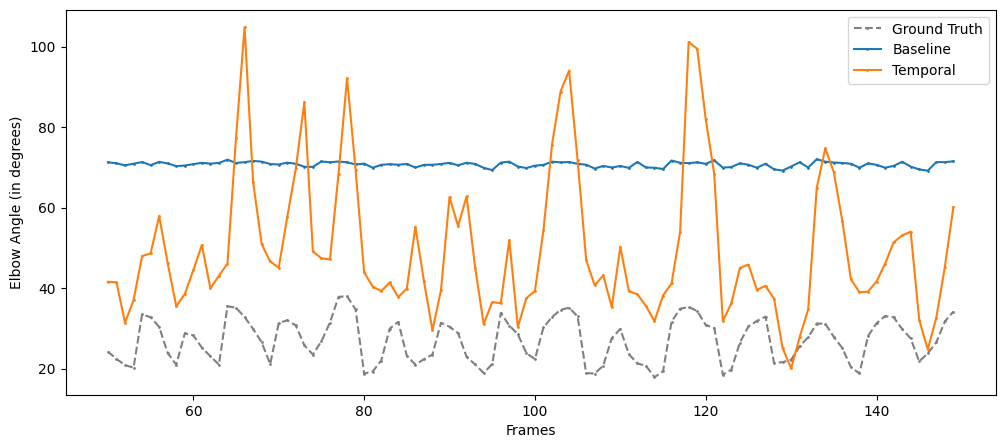

In [98]:
# Graph for angle for M3 weirdness. the baseline model is not learning elbow movements. 
import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]

def build_angle(data, arm):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    print(data.shape)
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[arm[0]]
        elbow_coords = frame_data[arm[1]]
        wrist_coords = frame_data[arm[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    print(angles)
    return angles

EXPERIMENT = "ABFA"
MODEL = "A3"
ARM = RIGHT_ARM

start_index = 50
end_index = 150
EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
MODEL_PATH = os.path.join("..", "model", "main_tests")

baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

ground_truth = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT}.npy"))[start_index:end_index]
baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

# training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


baseline_predictions = baseline_model.predict(baseline_data)
temporal_predictions = temporal_model.predict(temporal_data)

gt_angle = build_angle(ground_truth, ARM)
baseline_angle = build_angle(baseline_predictions, ARM )
temporal_angle = build_angle(temporal_predictions, ARM)
# training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(12,5))
plt.plot(x_axis, gt_angle, marker='o', markersize=1, label="Ground Truth", color='grey', linestyle="--")
plt.plot(x_axis, baseline_angle, marker='o', markersize=1, label="Baseline")
# plt.plot(x_axis, training_angle, marker='o', markersize=6, label='training')
plt.plot(x_axis, temporal_angle, marker='o', markersize=1, label="Temporal")
plt.legend(loc="upper right")
plt.xlabel("Frames")
plt.ylabel("Elbow Angle (in degrees)")
plt.show()


4/4 [==============================] - 0s 8ms/step
(100, 3, 19)
[119.82802899412208, 85.23353879434583, 62.60696960742363, 27.23536705422923, 43.40129384676931, 54.37969763953173, 93.54817778584616, 110.5894829099307, 142.8683757924999, 162.48629698398562, 172.60020118297243, 170.35059422308018, 135.3412293784591, 123.1605481572499, 93.03247273333659, 65.85430084331622, 45.28416596524665, 44.00904674677356, 58.001388176652114, 104.38228410483858, 134.5500005469759, 152.80686156208557, 172.72593406734467, 167.958902529661, 163.07559794474795, 148.92193416619926, 123.6959691286481, 98.4847159495799, 83.70794165773613, 43.75774049879462, 34.29656941420458, 43.004321302686805, 80.65467605102916, 102.26857544348194, 140.77902607461485, 161.74346105286986, 172.21264237137936, 152.56220648959808, 142.21552262436958, 119.81636806277399, 106.89581973276763, 85.97639496716349, 52.905920916761026, 38.24403056423645, 51.567886584051124, 69.97394593904428, 104.2570032084244, 142.63159316438887, 163

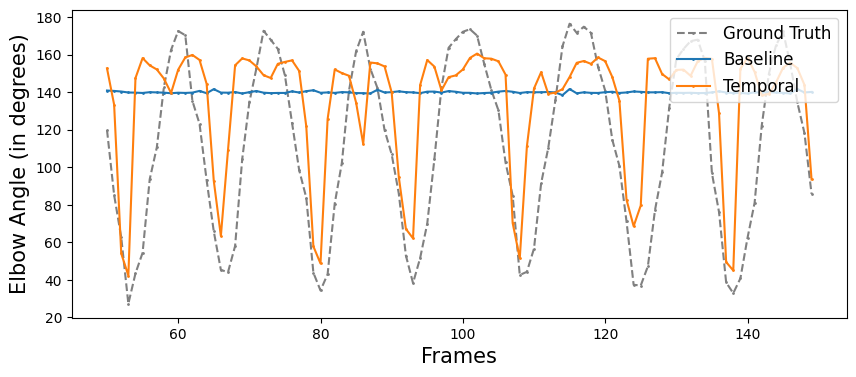

In [120]:
# Graph angle for M2, symmetry check, 


import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]

def build_angle(data, ARM):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    print(data.shape)
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[ARM[0]]
        elbow_coords = frame_data[ARM[1]]
        wrist_coords = frame_data[ARM[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    print(angles)
    return angles

# test: CCEA, LEft arm
EXPERIMENT = "CCEA"
arm = LEFT_ARM



MODEL = "A2"
start_index = 50
end_index = 150
EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
MODEL_PATH = os.path.join("..", "model", "main_tests")

baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

ground_truth = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT}.npy"))[start_index:end_index]
baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


baseline_predictions = baseline_model.predict(baseline_data)
temporal_predictions = temporal_model.predict(temporal_data)

gt_angle = build_angle(ground_truth, arm)
baseline_angle = build_angle(baseline_predictions, arm)
temporal_angle = build_angle(temporal_predictions, arm)
# training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(10,4))
plt.plot(x_axis, gt_angle, marker='o', markersize=1, label="Ground Truth", color='grey', linestyle="--")
plt.plot(x_axis, baseline_angle, marker='o', markersize=1, label="Baseline")
# plt.plot(x_axis, training_angle, marker='o', markersize=6, label='training')
plt.plot(x_axis, temporal_angle, marker='o', markersize=1, label="Temporal")
plt.legend(loc="upper right", fontsize=12)
plt.xlabel("Frames", fontsize=15)
plt.ylabel("Elbow Angle (in degrees)", fontsize=15)
plt.show()




4/4 [==============================] - 0s 6ms/step
(100, 3, 19)
[14.818196860212506, 22.12250075767662, 27.2737610047982, 32.72944542538498, 37.39172355056096, 47.66223828737604, 52.743702442161236, 62.73301475551452, 66.9365536662562, 65.76407534914915, 54.25666579179403, 38.620692489778506, 31.837193077482212, 22.70421381794998, 18.38697435172699, 15.374070125982554, 18.28246384459576, 22.07904917754555, 28.457849046185054, 30.563312144829386, 33.514428664604665, 31.8963470410126, 28.416230426620604, 21.97957555575837, 18.269948714369097, 14.076958755313182, 17.3515842725812, 19.1017185494661, 27.354337094388185, 37.10070896361793, 41.16353196676335, 46.79723704283086, 50.33812007631878, 58.49213579844528, 63.09450342957575, 62.353226100331476, 53.152109858242376, 47.05815683358023, 35.24635680560308, 24.53592131820795, 22.42708030089589, 18.028167368735073, 18.0523087482326, 20.148937668598947, 24.987111480096875, 27.39217306161754, 31.13041108336952, 33.60831470811742, 34.587270496

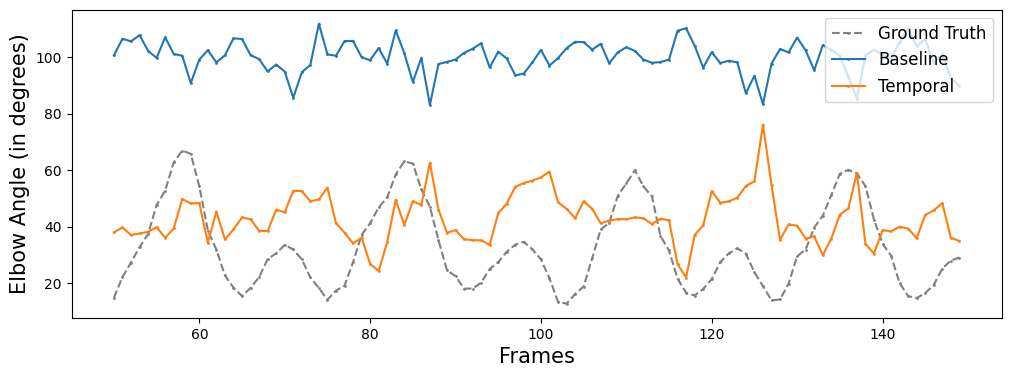

In [122]:
# Graph angle for M1, checking Left and Right arm movements


import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]

def build_angle(data, ARM):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    print(data.shape)
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[ARM[0]]
        elbow_coords = frame_data[ARM[1]]
        wrist_coords = frame_data[ARM[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    print(angles)
    return angles

# test: CAEA, LEft arm
EXPERIMENT = "AAFA"
arm = RIGHT_ARM

# train: CADA, right arm
# EXPERIMENT = "CADA"
# arm = LEFT_ARM

MODEL = "A1"
start_index = 50
end_index = 150
EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
MODEL_PATH = os.path.join("..", "model", "main_tests")

baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

ground_truth = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT}.npy"))[start_index:end_index]
baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


baseline_predictions = baseline_model.predict(baseline_data)
temporal_predictions = temporal_model.predict(temporal_data)

gt_angle = build_angle(ground_truth, arm)
baseline_angle = build_angle(baseline_predictions, arm)
temporal_angle = build_angle(temporal_predictions, arm)
# training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(12,4))
plt.plot(x_axis, gt_angle, marker='o', markersize=1, label="Ground Truth", color='grey', linestyle="--")
plt.plot(x_axis, baseline_angle, marker='o', markersize=1, label="Baseline")
# plt.plot(x_axis, training_angle, marker='o', markersize=6, label='training')
plt.plot(x_axis, temporal_angle, marker='o', markersize=1, label="Temporal")
plt.legend(loc="upper right", fontsize=12)
plt.xlabel("Frames", fontsize=15)
plt.ylabel("Elbow Angle (in degrees)", fontsize=15)
plt.show()




(100, 3, 19)
(100, 3, 19)
(100, 3, 19)
(100, 3, 19)


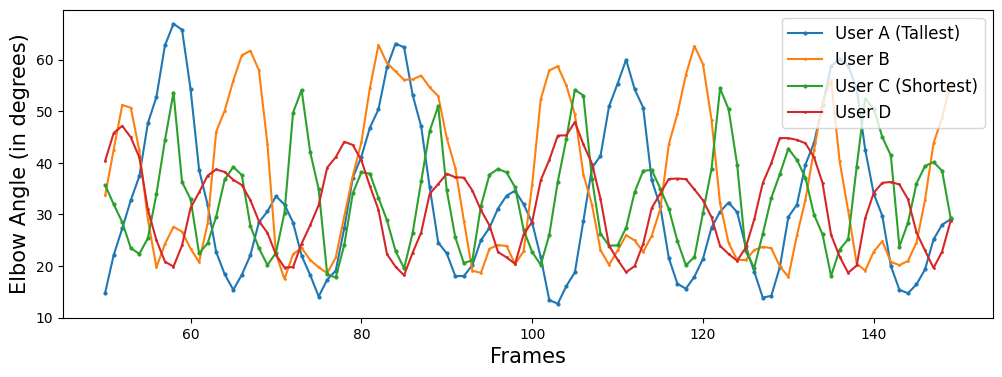

In [137]:
# Graph for the same angle between four users for elbow


import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]

def build_angle(data, ARM):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    print(data.shape)
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[ARM[0]]
        elbow_coords = frame_data[ARM[1]]
        wrist_coords = frame_data[ARM[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    return angles

# test: CAEA, LEft arm
EXPERIMENT_1 = "AAFA"
EXPERIMENT_2 = "BAFA"
EXPERIMENT_3 = "CAFA"
EXPERIMENT_4 = "DAFA"
arm = RIGHT_ARM

# train: CADA, right arm
# EXPERIMENT = "CADA"
# arm = LEFT_ARM

# MODEL = "U1"
start_index = 50
end_index = 150
# EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
# MODEL_PATH = os.path.join("..", "model", "main_tests")

# baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
# temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

ground_truth_1 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_1}.npy"))[start_index:end_index]
ground_truth_2 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_2}.npy"))[start_index:end_index]
ground_truth_3 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_3}.npy"))[start_index:end_index]
ground_truth_4 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_4}.npy"))[start_index:end_index]

# baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
# temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

# training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


# baseline_predictions = baseline_model.predict(baseline_data)
# temporal_predictions = temporal_model.predict(temporal_data)

gt_angle_1 = build_angle(ground_truth_1, arm)
gt_angle_2 = build_angle(ground_truth_2, arm)
gt_angle_3 = build_angle(ground_truth_3, arm)
gt_angle_4 = build_angle(ground_truth_4, arm)

# baseline_angle = build_angle(baseline_predictions, arm)
# temporal_angle = build_angle(temporal_predictions, arm)
# # training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(12,4))
plt.plot(x_axis, gt_angle_1, marker='o', markersize=2, label="User A (Tallest)")
plt.plot(x_axis, gt_angle_2, marker='o', markersize=1, label="User B")
plt.plot(x_axis, gt_angle_3, marker='o', markersize=2, label='User C (Shortest)')
plt.plot(x_axis, gt_angle_4, marker='o', markersize=1, label="User D")
plt.legend(loc="upper right", fontsize=12)
plt.xlabel("Frames", fontsize=15)
plt.ylabel("Elbow Angle (in degrees)", fontsize=15)
plt.show()





(63,)
(45,)
(40,)
(48,)
(43,)
(51,)
(43,)
(37,)
(44,)
(24,)
(42,)
(48,)
(57,)
(37,)
(47,)
(54,)
(51,)
(46,)
(49,)
(28,)
(35,)
(21,)
(27,)
(46,)
(47,)
(49,)
(61,)
(60,)
(44,)
(48,)
(38,)
(38,)
(26,)
(45,)
(32,)
(22,)
(41,)
(1,)
(41,)
(44,)
(45,)
(36,)
(51,)
(42,)
(36,)
(58,)
(36,)
(31,)
(35,)
(54,)
(50,)
(47,)
(59,)
(53,)
(58,)
(57,)
(53,)
(47,)
(56,)
(49,)
(44,)
(35,)
(30,)
(60,)
(59,)
(43,)
(32,)
(35,)
(36,)
(30,)
(55,)
(57,)
(44,)
(39,)
(22,)
(37,)
(1,)
(60,)
(59,)
(50,)
(51,)
(32,)
(32,)
(38,)
(39,)
(35,)
(25,)
(4,)
(36,)
(41,)
(52,)
(44,)
(50,)
(42,)
(49,)
(43,)
(37,)
(46,)
(28,)
(26,)
(22,)
(9,)
(15,)
(4,)
(32,)
(39,)
(32,)
(52,)
(33,)
(32,)
(44,)
(38,)
(28,)
(28,)
(30,)
(19,)
(27,)
(29,)
(1,)
(9,)
(18,)
(28,)
(40,)
(39,)
(26,)
(17,)
(14,)
(30,)
(34,)
(25,)
(26,)
(8,)
(18,)
(10,)
(10,)
(3,)
(35,)
(35,)
(44,)
(30,)
(39,)
(35,)
(28,)
(18,)
(23,)
(29,)
(13,)
(4,)
(7,)
(32,)
(35,)
(21,)
(27,)
(13,)
(12,)
(30,)
(17,)
(1,)
(37,)
(20,)
(34,)
(34,)
(30,)
(32,)
(6,)
(1,)
(11,)
(30,)
(31,)


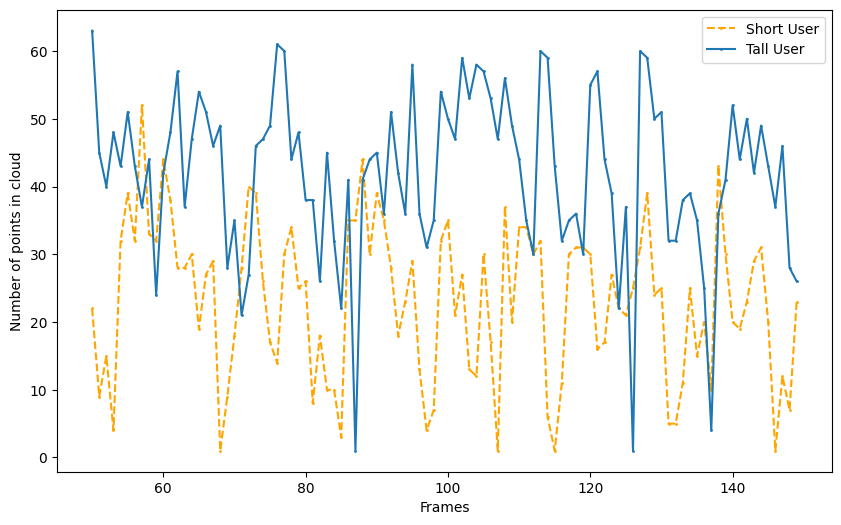

In [ ]:
# mars pt cloud between shortest and tallest user
# Graph for the same angle between four users for elbow
# Graph angle for M1, combination check, 


import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]


def calculate_pt_cloud(data):
    pt_count = []
    num_frames = data.shape[0]
    for i in range(num_frames):
        frame_data = data[i][0]
        x_values = frame_data[:,:,0]
        y_values = frame_data[:,:,1]
        z_values = frame_data[:,:,2]

        non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

        # Apply the mask to all data arrays
        x_filtered = x_values[non_zero_mask]
        y_filtered = y_values[non_zero_mask]
        z_filtered = z_values[non_zero_mask]
        # print(x_filtered.shape)
        pt_count.append(len(x_filtered))
    return pt_count

# test: CAEA, LEft arm
EXPERIMENT_1 = "AAFA"
# EXPERIMENT_2 = "BAFA"
EXPERIMENT_3 = "CAFA"
# EXPERIMENT_4 = "DAFA"
arm = RIGHT_ARM

# train: CADA, right arm
# EXPERIMENT = "CADA"
# arm = LEFT_ARM

# MODEL = "U1"
start_index = 50
end_index = 150
# EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
# MODEL_PATH = os.path.join("..", "model", "main_tests")

# baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
# temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

pt_cloud_tall = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT_1}.npy"))[start_index:end_index]
pt_cloud_short = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT_3}.npy"))[start_index:end_index]

pt_tall = calculate_pt_cloud(pt_cloud_tall)
pt_short = calculate_pt_cloud(pt_cloud_short)
print(f"Tall: {sum(pt_tall)/len(pt_tall)}")
print(f"Short: {sum(pt_short)/len(pt_short)}")

# ground_truth_3 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_3}.npy"))[start_index:end_index]
# ground_truth_4 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_4}.npy"))[start_index:end_index]

# baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
# temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

# training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


# baseline_predictions = baseline_model.predict(baseline_data)
# temporal_predictions = temporal_model.predict(temporal_data)

# gt_angle_1 = build_angle(ground_truth_1, arm)
# gt_angle_2 = build_angle(ground_truth_2, arm)
# gt_angle_3 = build_angle(ground_truth_3, arm)
# gt_angle_4 = build_angle(ground_truth_4, arm)

# baseline_angle = build_angle(baseline_predictions, arm)
# temporal_angle = build_angle(temporal_predictions, arm)
# # training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(10,6))
plt.plot(x_axis, pt_short, marker='o', markersize=1, label="Short User", color='orange', linestyle="--")
plt.plot(x_axis, pt_tall, marker='o', markersize=1, label="Tall User")
# plt.plot(x_axis, gt_angle_3, marker='o', markersize=6, label='training')
# plt.plot(x_axis, gt_angle_4, marker='o', markersize=1, label="Temporal")
plt.legend(loc="upper right")
plt.xlabel("Frames")
plt.ylabel("Number of points in cloud")
plt.show()






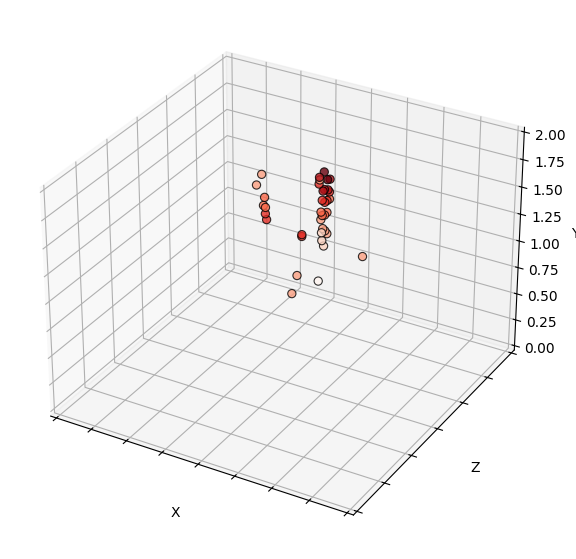

In [155]:
# Graph between the shortest and tallest point cloud: point cloud

# Noise difference between baseline and temporal mars
# Environment noise difference

import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const

DATA_PATH = os.path.join('..', 'dataset_main', 'expformatted', 'mars')
# TMARS_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")
# models = ['bmars', 'tmars']
EXPERIMENT = "AACA"
chosen_index = 110

def setup_3D_subplot(subplot):
    axis_dim = const.V_3D_AXIS
    subplot.set_xlim(-4, 4)
    subplot.set_ylim(0, 3)
    subplot.set_zlim(0, 2)
    subplot.set_xlabel("X")
    subplot.set_ylabel("Z")
    subplot.set_zlabel("Y")
    subplot.set_xticklabels([])
    subplot.set_yticklabels([])
    # subplot.invert_yaxis()
    subplot.invert_xaxis()
    return subplot.scatter([], [], [])

data = np.load(os.path.join(DATA_PATH, f"{EXPERIMENT}.npy"))
data = data[chosen_index][0]        
x_values = data[:,:,0]
y_values = data[:,:,1]
z_values = data[:,:,2]
intensity = data[:,:,3]



non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

    # Apply the mask to all data arrays
x_filtered = x_values[non_zero_mask]
y_filtered = y_values[non_zero_mask]
z_filtered = z_values[non_zero_mask]

    
intensity = intensity[non_zero_mask]
    # print(min(x_filtered.tolist()))

# plt.clear()
fig = plt.figure(figsize=(10, 7)) # Set the figure size for better visualization
ax = fig.add_subplot(111, projection='3d')
setup_3D_subplot(ax)
scatter = ax.scatter(x_filtered, y_filtered, z_filtered, c=intensity, cmap='Reds', s=35, alpha=0.8,
                          edgecolors='black',
        linewidth=0.8)
# cbar = plt.colorbar(scatter)
# cbar.set_label("Received Signal Intensity")





Tall: 18.77
Short: 8.09


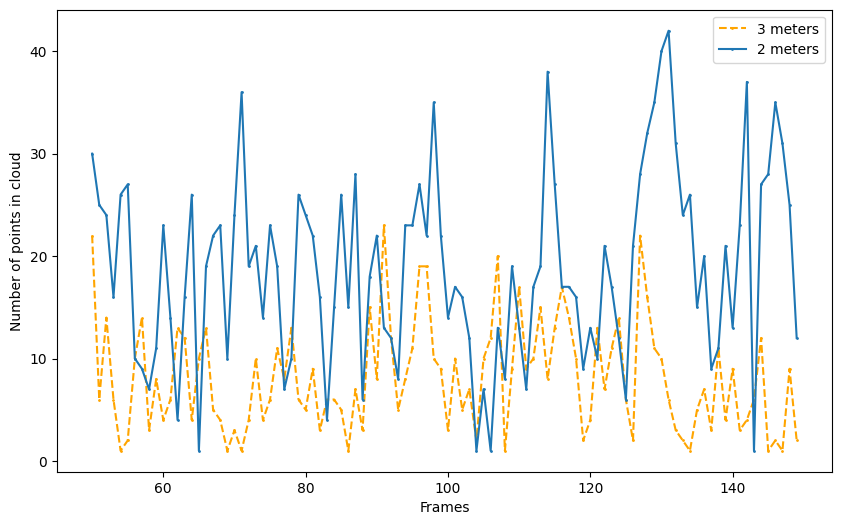

In [329]:
# MARS pt cloud count graph


import matplotlib.pyplot as plt
import numpy as np
import os
from keras.models import load_model

RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]


def calculate_pt_cloud(data):
    pt_count = []
    num_frames = data.shape[0]
    for i in range(num_frames):
        frame_data = data[i][0]
        x_values = frame_data[:,:,0]
        y_values = frame_data[:,:,1]
        z_values = frame_data[:,:,2]

        non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

        # Apply the mask to all data arrays
        x_filtered = x_values[non_zero_mask]
        y_filtered = y_values[non_zero_mask]
        z_filtered = z_values[non_zero_mask]
        # print(x_filtered.shape)
        pt_count.append(len(x_filtered))
    return pt_count

# test: CAEA, LEft arm
EXPERIMENT_1 = "BAAA"
# EXPERIMENT_2 = "BAFA"
EXPERIMENT_3 = "BAAB"
# EXPERIMENT_4 = "DAFA"
arm = RIGHT_ARM

# train: CADA, right arm
# EXPERIMENT = "CADA"
# arm = LEFT_ARM

# MODEL = "U1"
start_index = 50
end_index = 150
# EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
# MODEL_PATH = os.path.join("..", "model", "main_tests")

# baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
# temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))

pt_cloud_tall = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT_1}.npy"))[start_index:end_index]
pt_cloud_short = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT_3}.npy"))[start_index:end_index]

pt_tall = calculate_pt_cloud(pt_cloud_tall)
pt_short = calculate_pt_cloud(pt_cloud_short)
print(f"Tall: {sum(pt_tall)/len(pt_tall)}")
print(f"Short: {sum(pt_short)/len(pt_short)}")

# ground_truth_3 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_3}.npy"))[start_index:end_index]
# ground_truth_4 = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", f"{EXPERIMENT_4}.npy"))[start_index:end_index]

# baseline_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mars", f"{EXPERIMENT}.npy"))[start_index:end_index]
# temporal_data = np.load(os.path.join(EXP_FORMATTED_PATH, "mmWave", f"{EXPERIMENT}.npy"))[start_index:end_index]

# training_data = np.load(os.path.join(EXP_FORMATTED_PATH, "kinect", "AACA.npy"))[start_index:end_index]


# baseline_predictions = baseline_model.predict(baseline_data)
# temporal_predictions = temporal_model.predict(temporal_data)

# gt_angle_1 = build_angle(ground_truth_1, arm)
# gt_angle_2 = build_angle(ground_truth_2, arm)
# gt_angle_3 = build_angle(ground_truth_3, arm)
# gt_angle_4 = build_angle(ground_truth_4, arm)

# baseline_angle = build_angle(baseline_predictions, arm)
# temporal_angle = build_angle(temporal_predictions, arm)
# # training_angle = build_angle(training_data)

x_axis = [i for i in range(start_index, end_index)]
plt.figure(figsize=(10,6))
plt.plot(x_axis, pt_short, marker='o', markersize=1, label="3 meters", color='orange', linestyle="--")
plt.plot(x_axis, pt_tall, marker='o', markersize=1, label="2 meters")
# plt.plot(x_axis, gt_angle_3, marker='o', markersize=6, label='training')
# plt.plot(x_axis, gt_angle_4, marker='o', markersize=1, label="Temporal")
plt.legend(loc="upper right")
plt.xlabel("Frames")
plt.ylabel("Number of points in cloud")
plt.show()






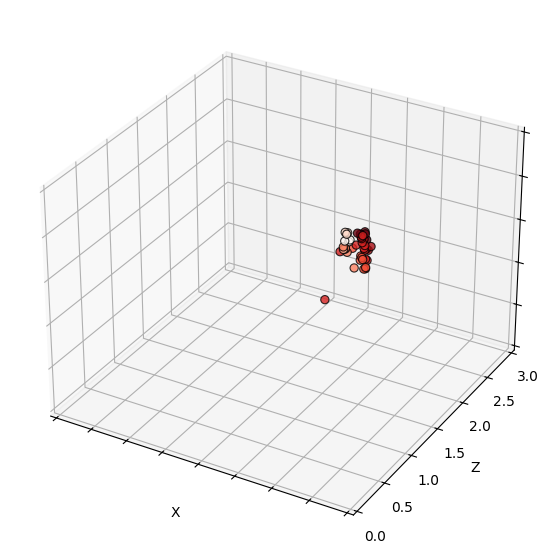

In [162]:
# mars pt cloud between distance 2m and 3m

# Noise difference between baseline and temporal mars
# Environment noise difference

import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const

DATA_PATH = os.path.join('..', 'dataset_main', 'expformatted', 'mars')
# TMARS_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")
# models = ['bmars', 'tmars']
EXPERIMENT = "AACB"
chosen_index = 115

def setup_3D_subplot(subplot):
    axis_dim = const.V_3D_AXIS
    subplot.set_xlim(-4, 4)
    subplot.set_ylim(0, 3)
    subplot.set_zlim(axis_dim[2][0], axis_dim[2][1])
    subplot.set_xlabel("X")
    subplot.set_ylabel("Z")
    subplot.set_zlabel("Y")
    subplot.set_xticklabels([])
    subplot.set_zticklabels([])
    # subplot.invert_yaxis()
    subplot.invert_xaxis()
    return subplot.scatter([], [], [])

data = np.load(os.path.join(DATA_PATH, f"{EXPERIMENT}.npy"))
data = data[chosen_index][0]        
x_values = data[:,:,0]
y_values = data[:,:,1]
z_values = data[:,:,2]
intensity = data[:,:,3]



non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

    # Apply the mask to all data arrays
x_filtered = x_values[non_zero_mask]
y_filtered = y_values[non_zero_mask]
z_filtered = z_values[non_zero_mask]

point_count = len(x_filtered)

intensity = intensity[non_zero_mask]
    # print(min(x_filtered.tolist()))

# plt.clear()
fig = plt.figure(figsize=(10, 7)) # Set the figure size for better visualization
ax = fig.add_subplot(111, projection='3d')
setup_3D_subplot(ax)
scatter = ax.scatter(x_filtered, y_filtered, z_filtered, c=intensity, cmap='Reds', s=35, alpha=0.8,
                          edgecolors='black',
        linewidth=0.8)# cbar = plt.colorbar(scatter)
# cbar.set_label("Received Signal Intensity")
# ax.set_title(f"Point Count: {point_count}", fontsize=16)





In [13]:
CONNECTIONS = [
            (0, 1),  # SpineBase to SpineMid
            (1, 18),  # SpineMid to SpineShoulder
            (2, 3),  # Neck to Head
            (18, 4),  # SpineShoulder to ShoulderLeft
            (18, 7),  # SpineShoulder to ShoulderRight
            (4, 5),  # ShoulderLeft to ElbowLeft
            (5, 6),  # ElbowLeft to WristLeft
            (7, 8),  # ShoulderRight to ElbowRight
            (8, 9),  # ElbowRight to WristRight
            (0, 14),  # SpineBase to HipRight
            (14, 15),  # HipRight to KneeRight
            (15, 16),  # KneeRight to AnkleRight
            (16, 17),  # AnkleRight to FootRight
            (0, 10),  # SpineBase to HipLeft
            (10, 11),  # HipLeft to KneeLeft
            (11, 12),  # KneeLeft to AnkleLeft
            (12, 13),  # AnkleLeft to FootLeft
            (2, 18),  # Neck to SpineShoulder
]

KEYPOINT_COLOURS = [
            "blue",  # SpineBase,
            "blue",  # SpineMid,
            "blue",  # Neck,
            "red",  # Head,
            "blue",  # ShoulderLeft,
            "green",  # ElbowLeft,
            "green",  # WristLeft,
            "blue",  # ShoulderRight,
            "green",  # ElbowRight,
            "green",  # WristRight,
            "blue",  # HipLeft,
            "green",  # KneeLeft,
            "green",  # AnkleLeft,
            "green",  # FootLeft,
            "blue",  # HipRight,
            "green",  # KneeRight,
            "green",  # AnkleRight,
            "green",  # FootRight,
            "blue",  # SpineShoulder
]

def setup_3D_subplot(subplot):
    axis_dim = const.V_3D_AXIS
    subplot.set_xlim(-1, 1)
    subplot.set_ylim(0, 2)
    subplot.set_zlim(0, 2)
    subplot.set_xlabel("X")
    subplot.set_ylabel("Z")
    subplot.set_zlabel("Y")
    # subplot.invert_yaxis()
    subplot.invert_xaxis()
    return subplot.scatter([], [], [])

def draw_skeleton(track, ax):
    track =track.reshape(3, -1)
    ax.clear()
    track[2] += 1
    setup_3D_subplot(ax)
    for connection in CONNECTIONS:
        keypoint_1 = connection[0]
        keypoint_2 = connection[1]

        x_values = [float(track[0][keypoint_1]), float(track[0][keypoint_2])]
        y_values = [float(track[2][keypoint_1]), float(track[2][keypoint_2])]
        z_values = [float(track[1][keypoint_1]), float(track[1][keypoint_2])]
        ax.plot(x_values, y_values, z_values, color="black")

    for keypoint_index in range(len(track[0])):
        color = KEYPOINT_COLOURS[keypoint_index]
        marker = (
            "o" if keypoint_index != 3 else "s"
        )  
        ax.scatter(
            float(track[0][keypoint_index]),
            float(track[2][keypoint_index]),
            float(track[1][keypoint_index]),
            c=color,
            marker=marker,
            s=15 if keypoint_index == 3 else 15, 
        )


(57,)


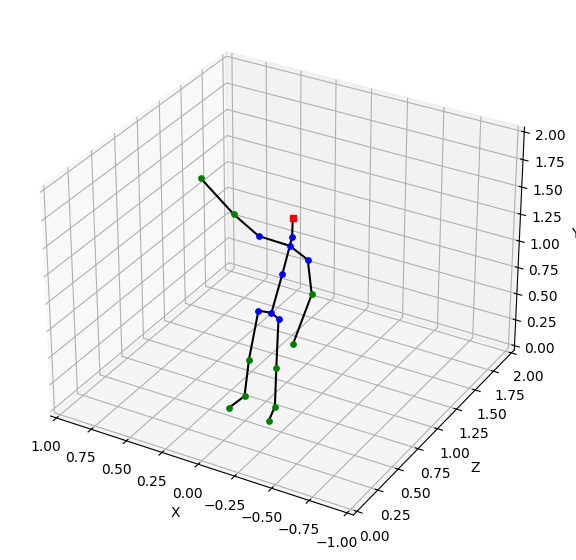

In [ ]:
# Example for different elbow angles, acceptable MAE. This basically visualizes the ground-truth currently. For example only

import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const

DATA_PATH = os.path.join('..', 'dataset_main', 'expformatted', 'kinect')
# TMARS_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")
# models = ['bmars', 'tmars']
EXPERIMENT_1 = "AAAA"
chosen_index_1 = 824

EXPERIMENT_2 = "AADA"
# chosen_index_2 = 


data = np.load(os.path.join(DATA_PATH, f"{EXPERIMENT}.npy"))
data = data[chosen_index]    
print(data.shape)

fig = plt.figure(figsize=(10, 7)) # Set the figure size for better visualization
ax = fig.add_subplot(111, projection='3d')
draw_skeleton(data, ax)
# setup_3D_subplot(ax)
# scatter = ax.scatter(x_filtered, y_filtered, z_filtered, c=intensity, cmap='Reds', s=30, alpha=0.8,
#                         edgecolors='gray',
#     linewidth=0.5)
# cbar = plt.colorbar(scatter)
# cbar.set_label("Received Signal Intensity")
# ax.set_title(f"Point Count: {point_count}", fontsize=16)





In [125]:
RIGHT_ARM = [8, 9, 10]
LEFT_ARM = [4,5,6]

def build_angle(data, ARM):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[ARM[0]]
        elbow_coords = frame_data[ARM[1]]
        wrist_coords = frame_data[ARM[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    return angles

In [37]:
# Calculating the pearson coefficient 

from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import os
import constants as const
from keras.models import load_model

def run_pearson_calc(experiment, model, arm):
    EXPERIMENT = experiment
    MODEL = model

    TEMPORAL_DATA_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")
    BASELINE_DATA_PATH = os.path.join("..", "dataset_main", "expformatted", "mars")
    GROUND_TRUTH_DATA_PATH = os.path.join("..", "dataset_main", "expformatted", "kinect")
    MODEL_PATH = os.path.join("..", "model", "main_tests")


    temporal_data = np.load(os.path.join(TEMPORAL_DATA_PATH, f"{EXPERIMENT}.npy"))
    baseline_data = np.load(os.path.join(BASELINE_DATA_PATH, f"{EXPERIMENT}.npy"))
    ground_truth = np.load(os.path.join(GROUND_TRUTH_DATA_PATH, f"{EXPERIMENT}.npy"))


    baseline_model = load_model(os.path.join(MODEL_PATH, f"bmars_{MODEL}.h5"))
    temporal_model = load_model(os.path.join(MODEL_PATH, f"tmars_{MODEL}.h5"))


    # Run the predictions

    prediction_base = baseline_model.predict(baseline_data, verbose=0)
    prediction_temporal = temporal_model.predict(temporal_data, verbose=0)

    # print(f"Shape: {prediction_base.shape} {prediction_temporal.shape} {ground_truth.shape}")


    #  Build the angle
    temporal_angles = build_angle(prediction_temporal, arm)
    baseline_angle = build_angle(prediction_base, arm)
    gt_angle = build_angle(ground_truth, arm)


    r_temporal, _ = pearsonr(temporal_angles, gt_angle)
    r_baseline, _ = pearsonr(baseline_angle, gt_angle)

    # print(r_temporal, r_baseline)
    return r_temporal, r_baseline



In [85]:
# A3 comparison for AAFA, DBFA
r_aafa_temporal, r_aafa_baseline = run_pearson_calc("ABFA", "A3", LEFT_ARM)

r_dbfa_temporal, r_dbfa_baseline = run_pearson_calc("ABFA", "A3", RIGHT_ARM)

print(f"AAFA , A3, left arm=  Base:{r_aafa_baseline}, Temporal:{r_aafa_temporal}")
print(f"AAFA , A3, right arm =  Base:{r_dbfa_baseline}, Temporal:{r_dbfa_temporal}")

# AAFA , A3, left arm=  Base:-0.09776982623592781, Temporal:0.45175426440063954
# DBFA , A3, right arm =  Base:-0.03730849633073726, Temporal:0.511698147931613

AAFA , A3, left arm=  Base:0.05399714963053294, Temporal:0.36690972621781404
AAFA , A3, right arm =  Base:0.12357988400421388, Temporal:0.463570433739805


In [109]:
# A1 comparison for AAFA
# res = run_pearson_calc("AAFA", "A1", RIGHT_ARM)
# print(f"AAFA, A1, Right arm = temporal: {res[0]} , baseline: {res[1]}")
# res = run_pearson_calc("AAFA", "A1", LEFT_ARM)
# print(f"AAFA, A1, Left arm = temporal: {res[0]} , baseline: {res[1]}")

# A2 comparison for CCEA
res = run_pearson_calc("BCEA", "A2", RIGHT_ARM)
print(f"CCEA, A2, Right arm = temporal: {res[0]} , baseline: {res[1]}")
res = run_pearson_calc("BCEA", "A2", LEFT_ARM)
print(f"CCEA, A2, Left arm = temporal: {res[0]} , baseline: {res[1]}")



# print(f"AAFA , A3 =  Base:{r_aafa_baseline}, Temporal:{r_aafa_temporal}")
# print(f"DBFA , A3 =  Base:{r_dbfa_baseline}, Temporal:{r_dbfa_temporal}")

(1661, 3, 19)
[91.7957669476921, 73.7774910490719, 72.0436785001358, 68.51860545734546, 70.48151230476456, 64.60774752464694, 58.16811439561223, 44.858316233829875, 47.83095958495341, 55.542318268603935, 52.89897965452248, 57.23984620539665, 49.15845345229343, 44.58378082766284, 39.730707843218646, 53.787221797450144, 68.11963373105435, 96.28536698249168, 92.02881937072743, 79.44552422440155, 69.53807716914362, 55.23910454395354, 66.68394634766189, 64.58291220042828, 67.69344047845017, 67.16012089446927, 48.858857565835756, 32.04314665322449, 33.114554607732586, 37.770962353917895, 45.05905195083173, 57.02093889432361, 67.81536183454115, 71.67380729945413, 71.4109508977796, 66.0023944099855, 63.69613936078178, 45.17235933729657, 51.698836737785015, 56.843493820371705, 63.84397001259428, 61.22487426237489, 48.12350607687624, 76.08036370171183, 89.94428906967347, 74.70492013262489, 58.31486395810949, 65.84505368221228, 57.5328397664512, 49.764538682615076, 62.14625708538396, 38.183069811

In [132]:
# Pearson coefficient for all users
import os
import numpy as np
from scipy.stats import pearsonr

GROUND_TRUTH_DATA = os.path.join("..", "dataset_main", "expformatted", "kinect")
USERS = ["A", "B", "C", "D"]

def return_exp_name(user):
    return f"{user}ACA"

user_data = []
for user in USERS:
    exp = return_exp_name(user)
    ground_truth = np.load(os.path.join(GROUND_TRUTH_DATA, f"{exp}.npy"))
    user_data.append(ground_truth)

output= {}
for i in range(4):
    for j in range(i+1, 4):
        # print(USERS[i], USERS[j])
        i_angles = build_angle(user_data[i], RIGHT_ARM)[100:300]
        j_angles = build_angle(user_data[j], RIGHT_ARM)[100:300]
        output[f"{USERS[i]}{USERS[j]}"] = pearsonr(i_angles, j_angles)[0]
        # print(len(i_angles))
print(output)

{'AB': -0.05940664310986451, 'AC': 0.21260826859107418, 'AD': 0.10355126658681581, 'BC': -0.13549285591725396, 'BD': 0.030086750319416093, 'CD': -0.005008284496413119}


In [143]:
# Calculating avg point cloud count between 2m and 3m

import os
import numpy as np

RAW_CLOUD_PATH = os.path.join("..", "dataset_main", "expformatted", "mars")

experiments = os.listdir(RAW_CLOUD_PATH)

distance_map = {
    "A":[],
    "B":[]
}
idx = 3
for exp in experiments:
    data = np.load(os.path.join(RAW_CLOUD_PATH, exp))
    for i in range(data.shape[0]):
        d = data[i][0]        
        x_values = d[:,:,0]
        y_values = d[:,:,1]
        z_values = d[:,:,2] 

        non_zero_mask = (x_values != 0) | (y_values != 0) | (z_values != 0)

            # Apply the mask to all data arrays
        x_filtered = x_values[non_zero_mask]
        y_filtered = y_values[non_zero_mask]
        z_filtered = z_values[non_zero_mask]

        point_count = len(x_filtered)
        # print(exp[idx])
        if exp[idx] in ["A","B"]:
            distance_map[exp[idx]].append(point_count)

# print(experiments)

In [ ]:
print(f"2m: {np.mean(distance_map['A'])}")
print(f"3m: {np.mean(distance_map['B'])}")



2m: 23.61609234357712
3m: 13.532020635520668


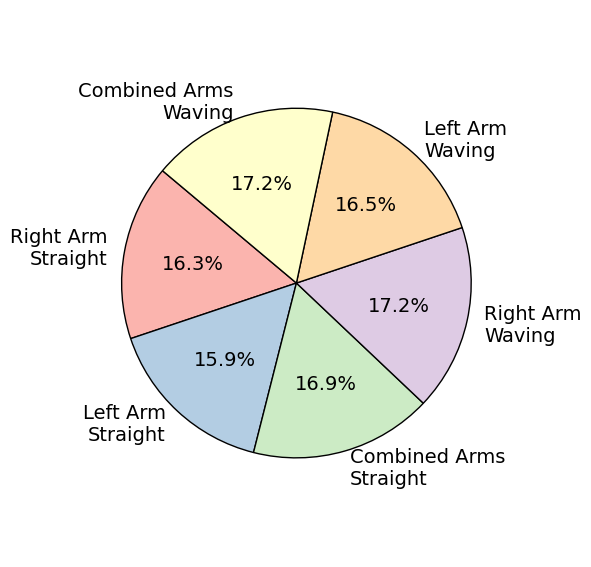

In [207]:
import os
import numpy

labels = {
    "E": {
        "A": "Clean",
        "B": "Medium\nClutter",
        "C": "High\nClutter"
    },
    "A": {
        "A": "Right Arm\nStraight",
        "B": "Left Arm\nStraight",
        "C": "Combined Arms\nStraight",
        "D": "Right Arm\nWaving",
        "E": "Left Arm\nWaving",
        "F": "Combined Arms\nWaving"
    },
    "U": {
        "A":"User A\n(1.83m)",
        "B":"User B\n(1.65m)",
        "C":"User C\n(1.55m)",
        "D":"User D\n(1.77m)"
    },
    "D":{
        "A": "2 meters",
        "B": "3 meters"
    }
}

dimension_idx = {
    "U": 0,
    "E": 1,
    "A": 2,
    "D": 3
}

DATA_PATH = os.path.join("..", "dataset_main", "expformatted", "mmWave")

def plot_pie(dimension):
    experiments = os.listdir(DATA_PATH)
    # print(experiments)
    distribution = {}
    for exp in experiments:
        if exp in ["T1.npy", "T2.npy"]:
            continue
        exp_data = np.load(os.path.join(DATA_PATH, f"{exp}"))
        if exp == "G1.npy":
            exp = "CBCA.npy"
        data_len = exp_data.shape[0]
        if exp[dimension_idx[dimension]] not in distribution:
            distribution[exp[dimension_idx[dimension]]] = 0
        if exp == "AAAA.npy" or exp == "CAAA.npy":
            data_len -= 1500
        distribution[exp[dimension_idx[dimension]]] += data_len

    codes = list(distribution.keys())
    figure_labels = [ labels[dimension][c] for c in codes]
    figure_sizes = [ distribution[c] for c in codes]
    plt.figure(figsize=(6, 6))
    plt.pie(figure_sizes, labels=figure_labels, autopct='%1.1f%%', startangle=140,
            labeldistance=1.1, # Adjust wedge label distance (can be > 1.0 for outside)
            textprops={'fontsize': 14},
                colors=plt.cm.Pastel1.colors,  # light pastel colors
            wedgeprops={'edgecolor': 'black', 'linewidth': 1} , # boundaries,
                radius=1.,  # keeps pie circle size fixed


)
    # plt.title(header)
    plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
    plt.tight_layout()
    plt.show()



plot_pie("A")

In [ ]:
import os
import numpy as np
from keras.models import load_model

def build_angle(data, ARM):
    n = data.shape[0]
    data = data.reshape(n, 3, 19)
    num_joints = 19
    print(data.shape)
    # Calculate the number of frames based on the number of joints.
    num_frames = n
    # List to store the calculated angles.
    angles = []

    # Iterate through each frame to calculate the angle.
    for i in range(num_frames):
        # Extract the joint data for the current frame.
        x = data[i, 0, :]
        y = data[i, 1, :]
        z = data[i, 2, :]

        # Stack into (joints, 3)
        frame_data = np.stack((x, y, z), axis=1)

        # Joint indices: shoulder=4, elbow=5, wrist=6
        shoulder_coords = frame_data[ARM[0]]
        elbow_coords = frame_data[ARM[1]]
        wrist_coords = frame_data[ARM[2]]



        # Define the two vectors that form the angle at the elbow joint.
        # Vector from shoulder to elbow.
        v_shoulder_elbow = elbow_coords - shoulder_coords
        # Vector from wrist to elbow.
        v_wrist_elbow = elbow_coords - wrist_coords

        # Calculate the dot product of the two vectors.
        dot_product = np.dot(v_shoulder_elbow, v_wrist_elbow)

        # Calculate the magnitudes of the two vectors.
        magnitude_v1 = np.linalg.norm(v_shoulder_elbow)
        magnitude_v2 = np.linalg.norm(v_wrist_elbow)

        # Handle the case where one or both vectors have a magnitude of zero
        # to prevent a division by zero error.
        if magnitude_v1 == 0 or magnitude_v2 == 0:
            angles.append(0)
            continue

        # Calculate the cosine of the angle using the dot product formula.
        cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

        # Clamp the cosine value to the range [-1.0, 1.0] to handle
        # potential floating-point inaccuracies that could cause a
        # domain error with np.arccos.
        cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

        # Calculate the angle in radians and convert it to degrees.
        angle_rad = np.arccos(cosine_angle)
        angle_deg = np.degrees(angle_rad)

        angles.append(angle_deg)
    return angles

def predict_eval(predicted, groundtruth):
   print(f"shape: {predicted.shape} {groundtruth.shape}")
   # Reshape to (n, 19, 3)
   pred_reshaped = predicted.reshape(-1, 19, 3)
   gt_reshaped = groundtruth.reshape(-1, 19, 3)
   
   # ---------- 1. Overall MAE ----------
   abs_error = np.abs(pred_reshaped - gt_reshaped)
   overall_mae = np.mean(abs_error)

   # ---------- 2. Joint-wise MAE ----------
   # Average over samples and coordinates per joint
   jointwise_mae = np.mean(abs_error, axis=(0, 2))  # shape: (19,)
   
   # ---------- 3. Overall Euclidean Distance (MPJPE) ----------
   euclidean_dist = np.linalg.norm(pred_reshaped - gt_reshaped, axis=2)  # shape: (n, 19)
   overall_euclidean_error = np.mean(euclidean_dist)

   # ---------- 4. Joint-wise Euclidean Distance ----------
   jointwise_euclidean_error = np.mean(euclidean_dist, axis=0)  # shape: (19,)

   return {
      "mae": overall_mae,
      "joint_mae": jointwise_mae.tolist(),
      "euc": overall_euclidean_error,
      "joint_euc": jointwise_euclidean_error.tolist()
   }
ARM_JOINTS = [4,5,6,8,9,10]

def extract_mae(result):
    return np.mean(np.array(result['joint_mae'])[ARM_JOINTS])

EXPERIMENT = "CAFA"
MODEL = "A1"
CHOSEN_IDX = 575

GT_PATH = os.path.join("..", "dataset_main", "expformatted", "kinect", f"{EXPERIMENT}.npy")
DATA_PATH = os.path.join("..","dataset_main", "expformatted", "mars", f"{EXPERIMENT}.npy")
MODEL_PATH = os.path.join("..", "model", "main_tests", f"bmars_{MODEL}.h5")
LEFT_ARM_JOINTS = [4,5,6]
RIGHT_ARM_JOINTS =  [8, 9, 10]

baseline_model = load_model(MODEL_PATH)
gt_data = np.load(GT_PATH)
mars_data = np.load(DATA_PATH)

print(gt_data.shape)
print(mars_data.shape)

prediction = baseline_model.predict(mars_data)
chosen_prediction = prediction[CHOSEN_IDX]
ground_truth = gt_data[CHOSEN_IDX]

error_results = predict_eval(chosen_prediction, ground_truth)
print(error_results['joint_mae'][ARM_JOINTS])


# print(chosen_prediction.shape , ground_truth.shape)
prediction_elbow_left = build_angle(prediction, LEFT_ARM_JOINTS)[CHOSEN_IDX]
prediction_elbow_right = build_angle(prediction, RIGHT_ARM_JOINTS)[CHOSEN_IDX]

gt_elb_left = build_angle(gt_data, LEFT_ARM_JOINTS)[CHOSEN_IDX]
gt_elb_right = build_angle(gt_data, RIGHT_ARM_JOINTS)[CHOSEN_IDX]
# print(len(prediction_elbow))
print(f"Prediction left:{prediction_elbow_left} right:{prediction_elbow_right}")
print(f"Ground Truth left: {gt_elb_left} right:{gt_elb_right}")
print(f"Avg: {((prediction_elbow_left - gt_elb_left) + (prediction_elbow_right - gt_elb_right))/2}")
# mars_data = mars_data[CHOSEN_IDX]

(1609, 57)
(1609, 1, 8, 8, 5)
51/51 [==============================] - 0s 2ms/step
shape: (57,) (57,)


TypeError: list indices must be integers or slices, not list